In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, explained_variance_score
import numpy as np

In [109]:
df = pd.read_csv("student performance.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [110]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [111]:
CINT=df.select_dtypes(include=["int64","float64"]).columns
cobj=df.select_dtypes(include= ["object"]).columns
print(f"numeriques:{CINT}")
print(f"catigorilles:{cobj}")

numeriques:Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')
catigorilles:Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')


In [112]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


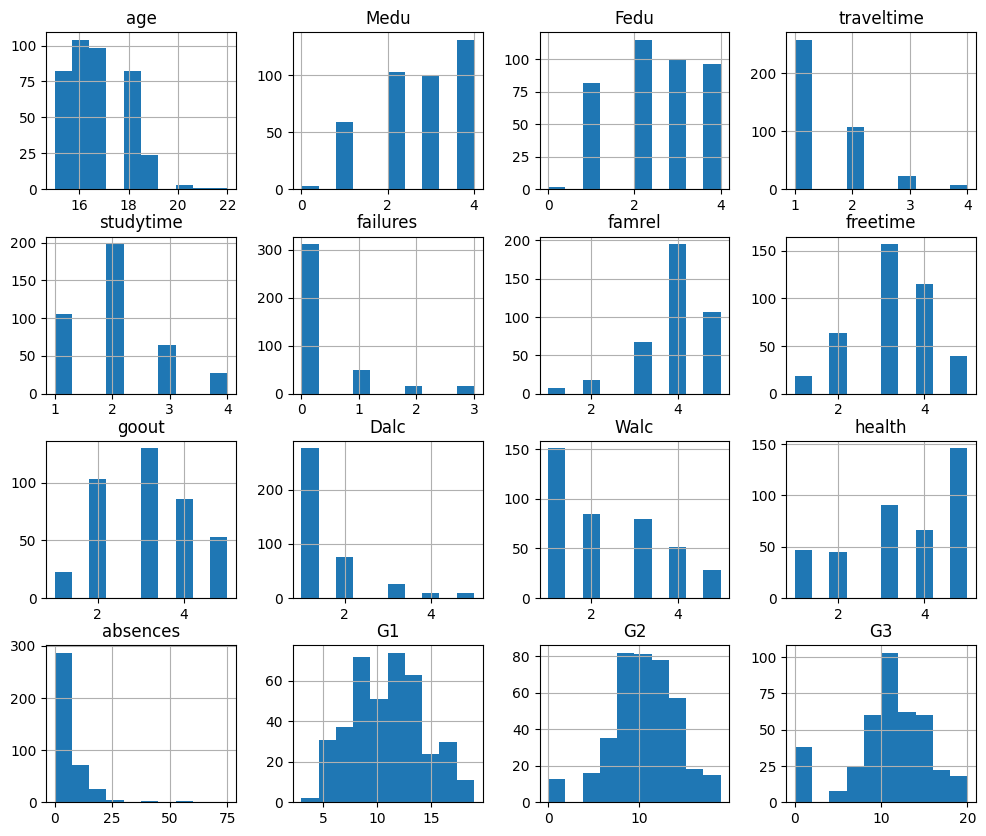

In [113]:
df.hist(figsize=(12,10))
plt.show()

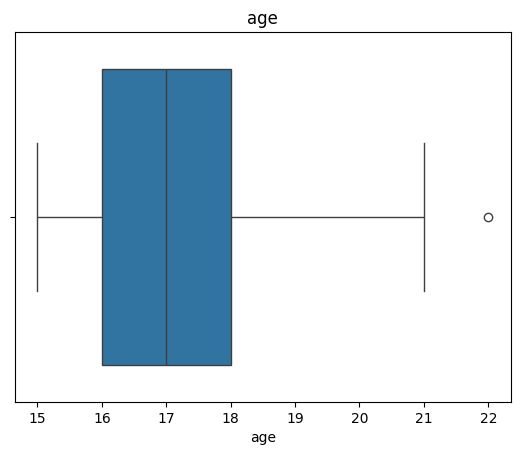

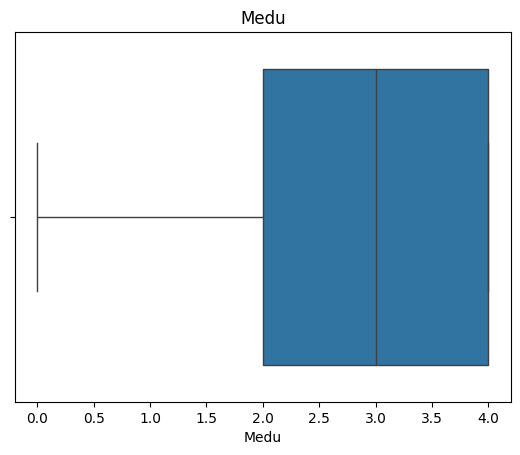

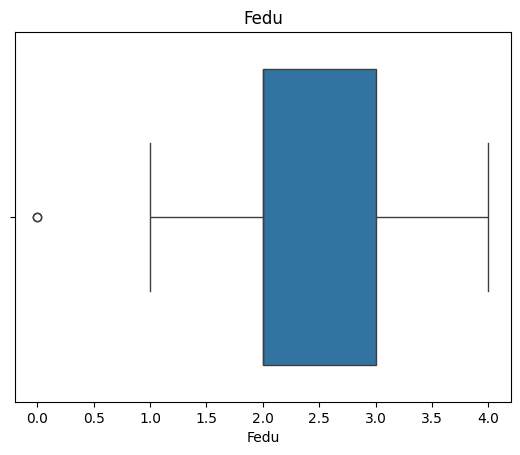

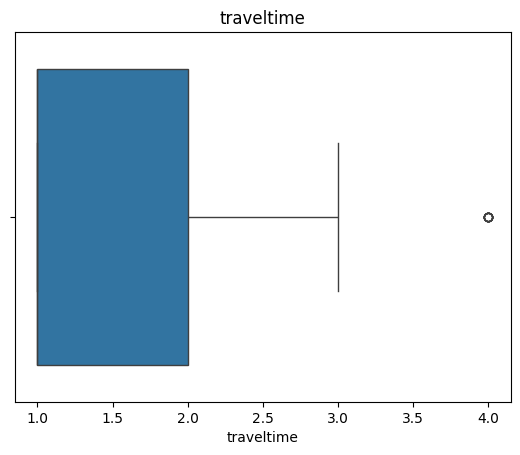

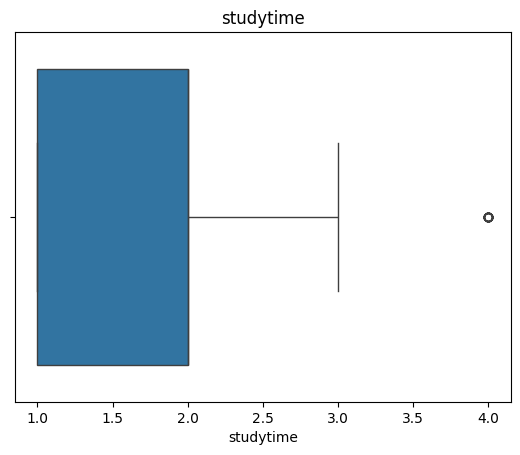

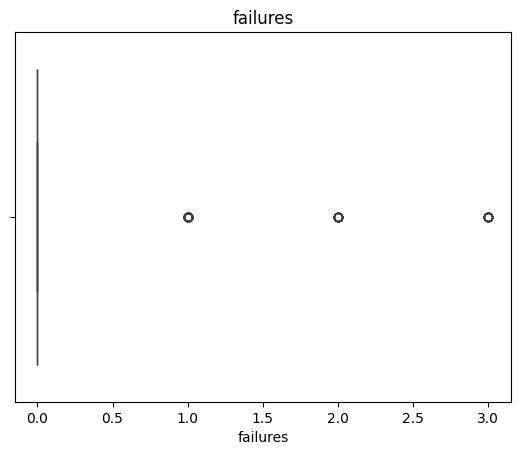

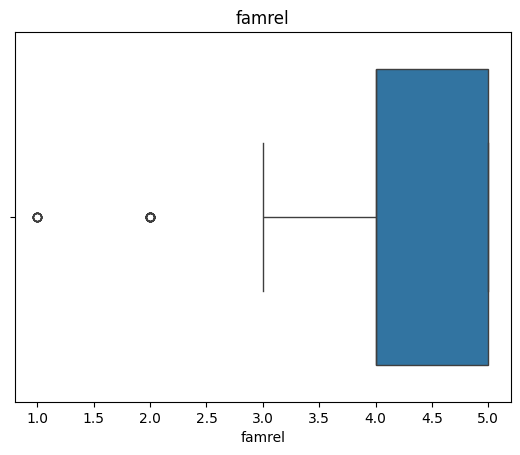

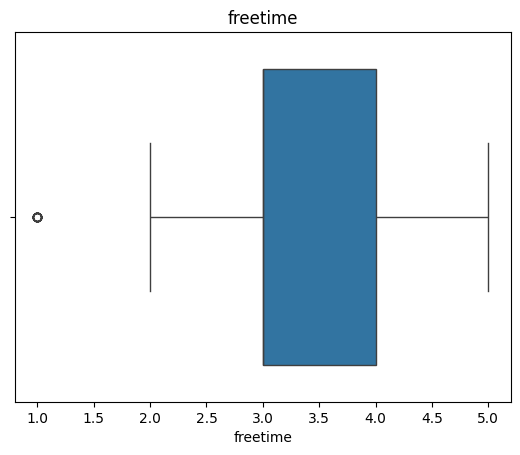

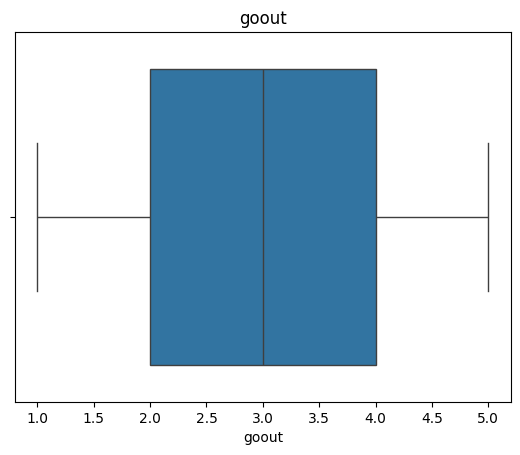

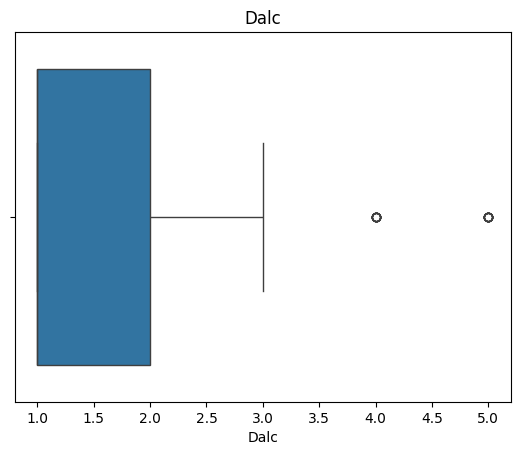

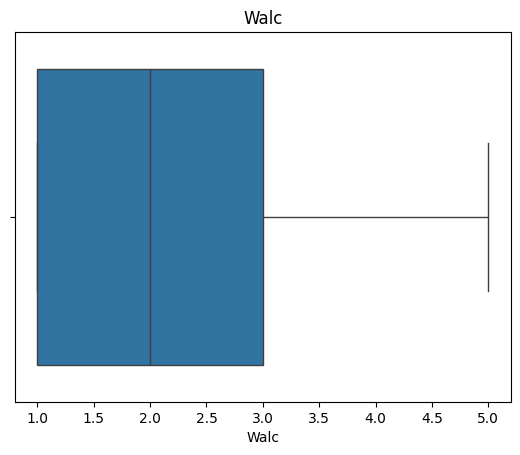

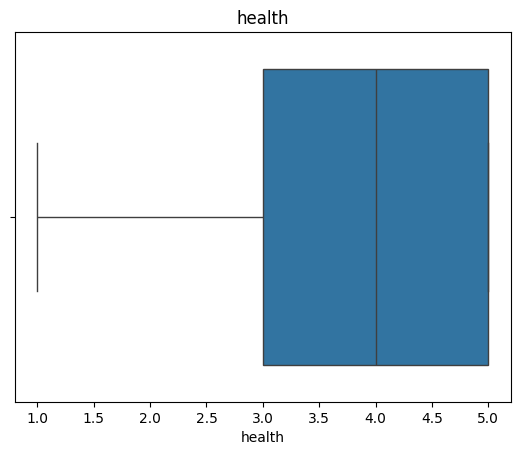

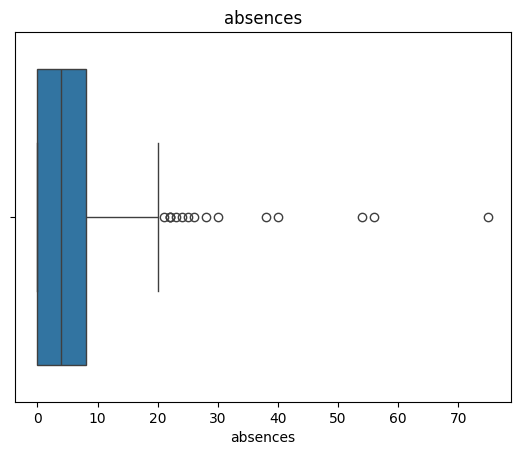

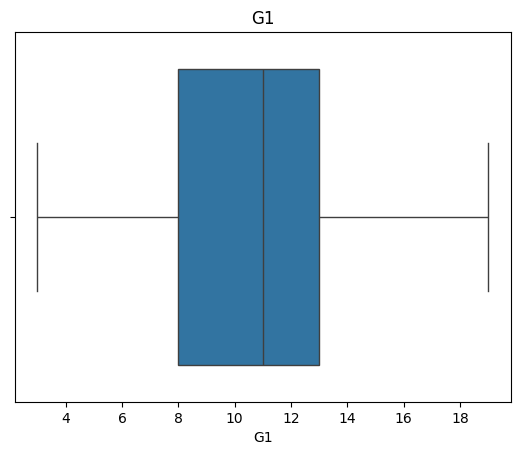

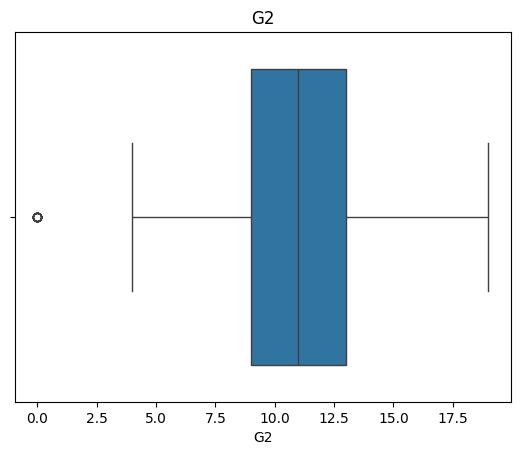

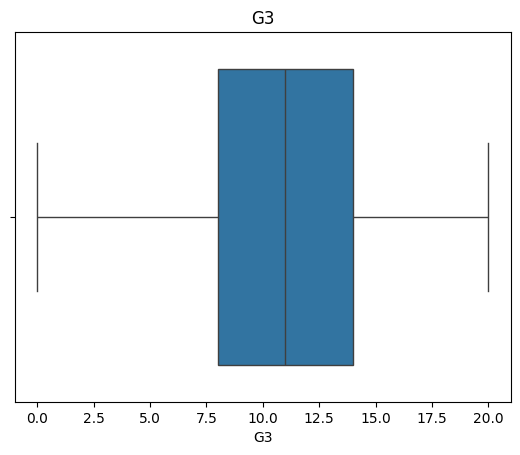

In [114]:
for col in CINT :
  sns.boxplot(x=df[col])
  plt.title(col)
  plt.show()


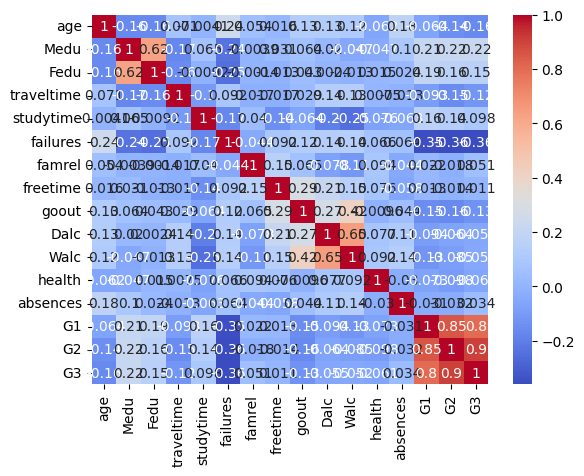

In [115]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [116]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [117]:
df = pd.get_dummies(df, drop_first=True)

In [118]:
scaler = StandardScaler()

In [119]:
num_df = df.select_dtypes(include='number')

num_df = num_df.loc[:, num_df.nunique() > 2]

In [120]:
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR))).any(axis=1)]

df = df_clean

In [121]:
X = df.drop("G3", axis=1)
y = df["G3"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [122]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [123]:
lr = LinearRegression()
rf = RandomForestRegressor()
dt = DecisionTreeRegressor()
svr = SVR()

lr.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)
svr.fit(X_train_scaled, y_train)

SVR()

In [124]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_svr = svr.predict(X_test_scaled)

In [125]:

def evaluate(y_test, y_pred, name):
    print("----", name, "----")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))
    print("MedAE:", median_absolute_error(y_test, y_pred))
    print("Explained Variance:", explained_variance_score(y_test, y_pred))
    print()

In [126]:
results = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Decision Tree": y_pred_dt,
    "SVR": y_pred_svr
}

for name, y_pred in results.items():
    evaluate( y_test, y_pred, name)

---- Linear Regression ----
MSE: 2.616506070592305
RMSE: 1.617561767164489
MAE: 1.1340032074270447
R2: 0.7433909647514473
MedAE: 0.7621790353803668
Explained Variance: 0.7497035739144836

---- Random Forest ----
MSE: 3.3398170212765947
RMSE: 1.8275166268126248
MAE: 1.2472340425531914
R2: 0.6724535695258391
MedAE: 0.9700000000000006
Explained Variance: 0.7060288669863257

---- Decision Tree ----
MSE: 10.0
RMSE: 3.1622776601683795
MAE: 1.702127659574468
R2: 0.019268335997158603
MedAE: 1.0
Explained Variance: 0.07680696146332822

---- SVR ----
MSE: 5.050195959226477
RMSE: 2.2472641053571065
MAE: 1.3154258348842434
R2: 0.5047112913367391
MedAE: 0.8177494183649028
Explained Variance: 0.514794300695407



In [127]:
scores = {}

for name, y_pred in results.items():
    scores[name] = r2_score(y_test, y_pred)

print(scores)
print("Best Model:", max(scores, key=scores.get))

{'Linear Regression': 0.7433909647514473, 'Random Forest': 0.6724535695258391, 'Decision Tree': 0.019268335997158603, 'SVR': 0.5047112913367391}
Best Model: Linear Regression
